# Lab 4 — Data Quality Assessment & Preprocessing
## Dataset: Iris Dataset

This notebook follows the **same five assignment tasks in Lab 4**, with the Iris dataset used instead of the Chocolate Sales dataset.

**Important:** For Task 4, all four numerical Iris features are normalized using both **Min-Max** and **Z-score (StandardScaler)**, exactly following the method demonstrated in the lab.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Google Colab: upload the Iris CSV file
from google.colab import files
import pandas as pd
import os

uploaded = files.upload()

# Find the uploaded CSV automatically
csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("Please upload the Iris CSV file.")

csv_file = csv_files[0]
df = pd.read_csv(csv_file)

print("Loaded file:", csv_file)
print("Dataset shape:", df.shape)
display(df.head())


Saving Iris_Dataset(1)(1) (1).csv to Iris_Dataset(1)(1) (1) (1).csv
Loaded file: Iris_Dataset(1)(1) (1) (1).csv
Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 1 — Identify data quality issues in the dataset

In [13]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (150, 5)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1


### Task 1 explanation
The Iris dataset contains four numerical features and one categorical target column (`species`).

The four numerical features are:
- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

The original dataset has no missing values. The `species` column is categorical and is not used as a numerical feature for normalization or PCA.

## Task 2 — Apply one missing value strategy and explain why

In [14]:
# Check the original missing values first
print("Original missing values:")
print(df.isnull().sum())

# The original Iris dataset has no missing values, so no imputation is required.
# We keep the original data unchanged for this task.
df_clean_missing = df.copy()

print("\nMissing values after handling:")
print(df_clean_missing.isnull().sum())

Original missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Missing values after handling:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


### Task 2 explanation
There are **no missing values** in the original Iris dataset, so no rows need to be dropped and no imputation is necessary.

If missing values were present, median imputation would be a suitable strategy for numerical features because it is less affected by extreme values than the mean.

## Task 3 — Detect and handle outliers using IQR

In [15]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound))

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": int(outliers.sum())
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,sepal length (cm),5.1,6.4,1.3,3.15,8.35,0
1,sepal width (cm),2.8,3.3,0.5,2.05,4.05,4
2,petal length (cm),1.6,5.1,3.5,-3.65,10.35,0
3,petal width (cm),0.3,1.8,1.5,-1.95,4.05,0


In [16]:
# Remove rows containing an IQR outlier in any numerical feature
keep_mask = pd.Series(True, index=df.index)

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    keep_mask &= df[feature].between(lower_bound, upper_bound)

df_no_outliers = df.loc[keep_mask].copy()

print("Original rows:", len(df))
print("Rows after IQR outlier removal:", len(df_no_outliers))
print("Rows removed:", len(df) - len(df_no_outliers))

Original rows: 150
Rows after IQR outlier removal: 146
Rows removed: 4


### Task 3 explanation
The IQR method uses:

**IQR = Q3 − Q1**

**Lower bound = Q1 − 1.5 × IQR**

**Upper bound = Q3 + 1.5 × IQR**

For this Iris dataset, 4 rows are identified as IQR outliers (all due to `sepal width (cm)`). These rows are removed before the later preprocessing analysis.

# Task 4 — Normalize numerical features using both Min-Max and Z-score

This section follows the normalization procedure demonstrated in the lab.

**Numerical features used:**
- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

The `species` column is not normalized because it is categorical.

In [17]:
# Numerical features to normalize
df_no_outliers[numerical_features].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Min-Max Normalization

Min-Max normalization rescales numerical values to a fixed range, usually **0 to 1**.

The transformation is:

**X_scaled = (X − X_min) / (X_max − X_min)**

The smallest value of each feature becomes 0 and the largest becomes 1.

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_no_outliers[numerical_features].copy()
df_scaled[numerical_features] = scaler.fit_transform(
    df_no_outliers[numerical_features]
)

print("Min-Max normalized data:")
display(df_scaled.head())

print("\nMinimum values:")
print(df_scaled.min())

print("\nMaximum values:")
print(df_scaled.max())

Min-Max normalized data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.722222,0.067797,0.041667
1,0.166667,0.444444,0.067797,0.041667
2,0.111111,0.555556,0.050847,0.041667
3,0.083333,0.500000,0.084746,0.041667
4,0.194444,0.777778,0.067797,0.041667



Minimum values:
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

Maximum values:
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


### Z-Score Normalization

Z-score standardization transforms each numerical feature so that its values are centered around **0** with a standard deviation of approximately **1**.

The transformation is:

**z = (X − mean) / standard deviation**

This is also the standardized form used before PCA in the lab.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df_no_outliers[numerical_features].copy()
df_standardized[numerical_features] = scaler.fit_transform(
    df_no_outliers[numerical_features]
)

print("Z-score standardized data:")
display(df_standardized.head())

print("\nMeans (approximately 0):")
print(df_standardized.mean())

print("\nStandard deviations (approximately 1):")
print(df_standardized.std(ddof=0))

Z-score standardized data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.910515,1.159151,-1.373764,-1.348525
1,-1.151122,-0.101922,-1.373764,-1.348525
2,-1.391729,0.402507,-1.430841,-1.348525
3,-1.512032,0.150292,-1.316687,-1.348525
4,-1.030819,1.411365,-1.373764,-1.348525



Means (approximately 0):
sepal length (cm)    7.300097e-16
sepal width (cm)     2.190029e-16
petal length (cm)    1.460019e-16
petal width (cm)    -9.733462e-17
dtype: float64

Standard deviations (approximately 1):
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


### Task 4 interpretation

- **Min-Max normalization:** scales every numerical feature to the range **0–1**.
- **Z-score standardization:** centers every numerical feature around **0** and scales its standard deviation to **1**.
- `species` is excluded because it is categorical.
- The same four numerical features are used for both transformations.

## Task 5 — Apply PCA and interpret explained variance

In [20]:
# PCA is applied to the Z-score standardized numerical features
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_standardized[numerical_features])

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

print("Explained variance ratio:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_.sum())

display(pca_df.head())

Explained variance ratio:
PC1: 0.7280832084559864
PC2: 0.22877251106706525
Total: 0.9568557195230516


,PC1,PC2
0,-2.337747,0.628592
1,-2.139290,-0.633311
2,-2.429209,-0.247052
3,-2.361216,-0.521362
4,-2.466128,0.822503


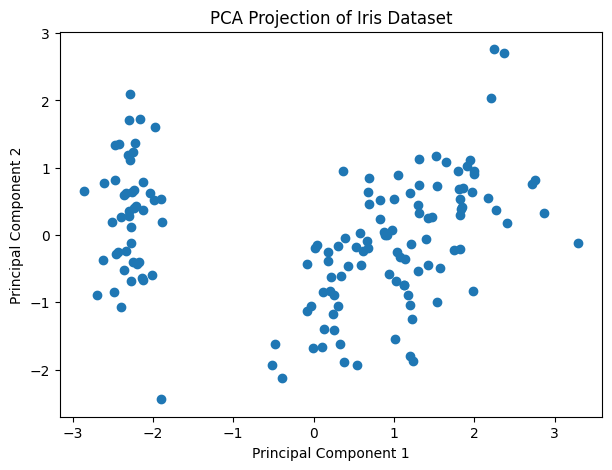

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")
plt.show()

### Task 5 interpretation

The first two principal components capture most of the variation in the four standardized numerical features.

The explained variance is calculated directly from the fitted PCA model above. PCA is applied after Z-score standardization so that features with larger numerical scales do not dominate the result.

# Final Submission Summary

- **Task 1:** Data quality was checked for data types, missing values, and duplicates.
- **Task 2:** The original Iris dataset has no missing values, so no imputation was required.
- **Task 3:** IQR was used to detect and remove numerical outliers.
- **Task 4:** All four numerical Iris features were normalized using **both Min-Max and Z-score**, exactly as required.
- **Task 5:** PCA was applied to the standardized numerical features and the explained variance was reported.

**Dataset used:** Iris Dataset  
**Target/categorical column:** `species`  
**Numerical features:** 4